# Air Quality Index in Jakarta




In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("senadu34/air-quality-index-in-jakarta-2010-2021")

print("Path to dataset files:", path)

100%|██████████| 357k/357k [00:00<00:00, 531kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/senadu34/air-quality-index-in-jakarta-2010-2021/versions/3


In [ ]:
import shutil

shutil.copytree(path, "data")

'data'

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [ ]:
df= pd.read_csv("/content/data/ispu_dki_all.csv")

## EDA

In [ ]:
df.shape

(5538, 11)

In [ ]:
df.head()

,tanggal,stasiun,pm25,pm10,so2,co,o3,no2,max,critical,categori
0,2010-01-01,DKI1 (Bunderan HI),NaN,60.0,4.0,73.0,27.0,14.0,73.0,CO,SEDANG
1,2010-01-02,DKI1 (Bunderan HI),NaN,32.0,2.0,16.0,33.0,9.0,33.0,O3,BAIK
2,2010-01-03,DKI1 (Bunderan HI),NaN,27.0,2.0,19.0,20.0,9.0,27.0,PM10,BAIK
3,2010-01-04,DKI1 (Bunderan HI),NaN,22.0,2.0,16.0,15.0,6.0,22.0,PM10,BAIK
4,2010-01-05,DKI1 (Bunderan HI),NaN,25.0,2.0,17.0,15.0,8.0,25.0,PM10,BAIK


In [ ]:
df.tail()

,tanggal,stasiun,pm25,pm10,so2,co,o3,no2,max,critical,categori
5533,2025-02-24,DKI3 (Jagakarsa),70.0,45.0,52.0,18.0,19.0,40.0,70.0,PM25,SEDANG
5534,2025-02-25,DKI5 (Kebon Jeruk),75.0,18.0,28.0,13.0,25.0,4.0,75.0,PM25,SEDANG
5535,2025-02-26,DKI3 (Jagakarsa),65.0,46.0,57.0,11.0,11.0,51.0,65.0,PM25,SEDANG
5536,2025-02-27,DKI5 (Kebon Jeruk),111.0,29.0,24.0,21.0,34.0,8.0,111.0,PM25,TIDAK SEHAT
5537,2025-02-28,DKI5 (Kebon Jeruk),71.0,20.0,24.0,9.0,31.0,6.0,71.0,PM25,SEDANG


In [ ]:
df.columns

Index(['tanggal', 'stasiun', 'pm25', 'pm10', 'so2', 'co', 'o3', 'no2', 'max',
       'critical', 'categori'],
      dtype='object')

 # Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5538 entries, 0 to 5537
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tanggal   5538 non-null   object 
 1   stasiun   5537 non-null   object 
 2   pm25      1516 non-null   float64
 3   pm10      5223 non-null   float64
 4   so2       5408 non-null   float64
 5   co        5450 non-null   float64
 6   o3        5434 non-null   float64
 7   no2       5432 non-null   float64
 8   max       5537 non-null   float64
 9   critical  5534 non-null   object 
 10  categori  5538 non-null   object 
dtypes: float64(7), object(4)
memory usage: 476.1+ KB


In [ ]:
df.memory_usage(deep=True)

,0
Index,132
tanggal,326742
stasiun,372727
pm25,44304
pm10,44304
so2,44304
co,44304
o3,44304
no2,44304
max,44304


# Missing Information

In [ ]:
df.isnull().sum()

,0
tanggal,0
stasiun,1
pm25,4022
pm10,315
so2,130
co,88
o3,104
no2,106
max,1
critical,4


In [ ]:
# Percentage of missing values
(df.isnull().sum() / len(df)) * 100

,0
tanggal,0.000000
stasiun,0.018057
pm25,72.625497
pm10,5.687974
so2,2.347418
co,1.589021
o3,1.877934
no2,1.914048
max,0.018057
critical,0.072228


In [ ]:
df = df.dropna(subset=['max'])


In [ ]:
df['stasiun'].fillna(df['stasiun'].mode()[0], inplace=True)


/tmp/ipython-input-1206798068.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['stasiun'].fillna(df['stasiun'].mode()[0], inplace=True)


In [ ]:
df['pm25'].fillna(df['pm25'].median(), inplace=True)


/tmp/ipython-input-3258518638.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['pm25'].fillna(df['pm25'].median(), inplace=True)


In [ ]:
num_cols = ['pm10','so2','co','o3','no2']
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)


/tmp/ipython-input-4067582774.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
df['critical'].fillna('Unknown', inplace=True)


/tmp/ipython-input-2310419787.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['critical'].fillna('Unknown', inplace=True)


In [ ]:
df.isnull().sum()

,0
tanggal,0
stasiun,0
pm25,0
pm10,0
so2,0
co,0
o3,0
no2,0
max,0
critical,0


In [ ]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
# Numerical summary
df.describe()

,pm25,pm10,so2,co,o3,no2,max
count,5537.000000,5537.000000,5537.000000,5537.000000,5537.000000,5537.000000,5537.000000
mean,89.929384,56.440672,22.332852,20.384685,77.308290,14.304678,97.625790
std,13.924039,19.435656,15.284167,11.875670,51.326724,9.960480,40.955382
min,10.000000,2.000000,0.000000,0.000000,4.000000,1.000000,0.000000
25%,90.000000,46.000000,11.000000,12.000000,36.000000,8.000000,70.000000
50%,90.000000,57.000000,18.000000,18.000000,69.000000,12.000000,90.000000
75%,90.000000,66.000000,31.000000,25.000000,102.000000,18.000000,114.000000
max,287.000000,187.000000,112.000000,119.000000,314.000000,202.000000,314.000000


In [ ]:
df.describe(include=object)

,tanggal,stasiun,critical,categori
count,5537,5537,5537,5537
unique,5537,5,7,6
top,2025-02-28,DKI4 (Lubang Buaya),O3,SEDANG
freq,1,1675,2970,3187


In [ ]:
df['tanggal'] = pd.to_datetime(df['tanggal'])


In [ ]:
df['year'] = df['tanggal'].dt.year
df['month'] = df['tanggal'].dt.month
df['day'] = df['tanggal'].dt.day


In [ ]:
df.drop(columns=['tanggal'], inplace=True)


In [ ]:
num_cols = df.select_dtypes(include=['float64',"int64"]).columns
cat_cols = df.select_dtypes(include=['object',"bool","category"]).columns
num_cols,cat_cols

(Index(['pm25', 'pm10', 'so2', 'co', 'o3', 'no2', 'max'], dtype='object'),
 Index(['stasiun', 'critical', 'categori'], dtype='object'))

In [ ]:
date_cols=["year","month","day"]

# Univariate Aanlysis

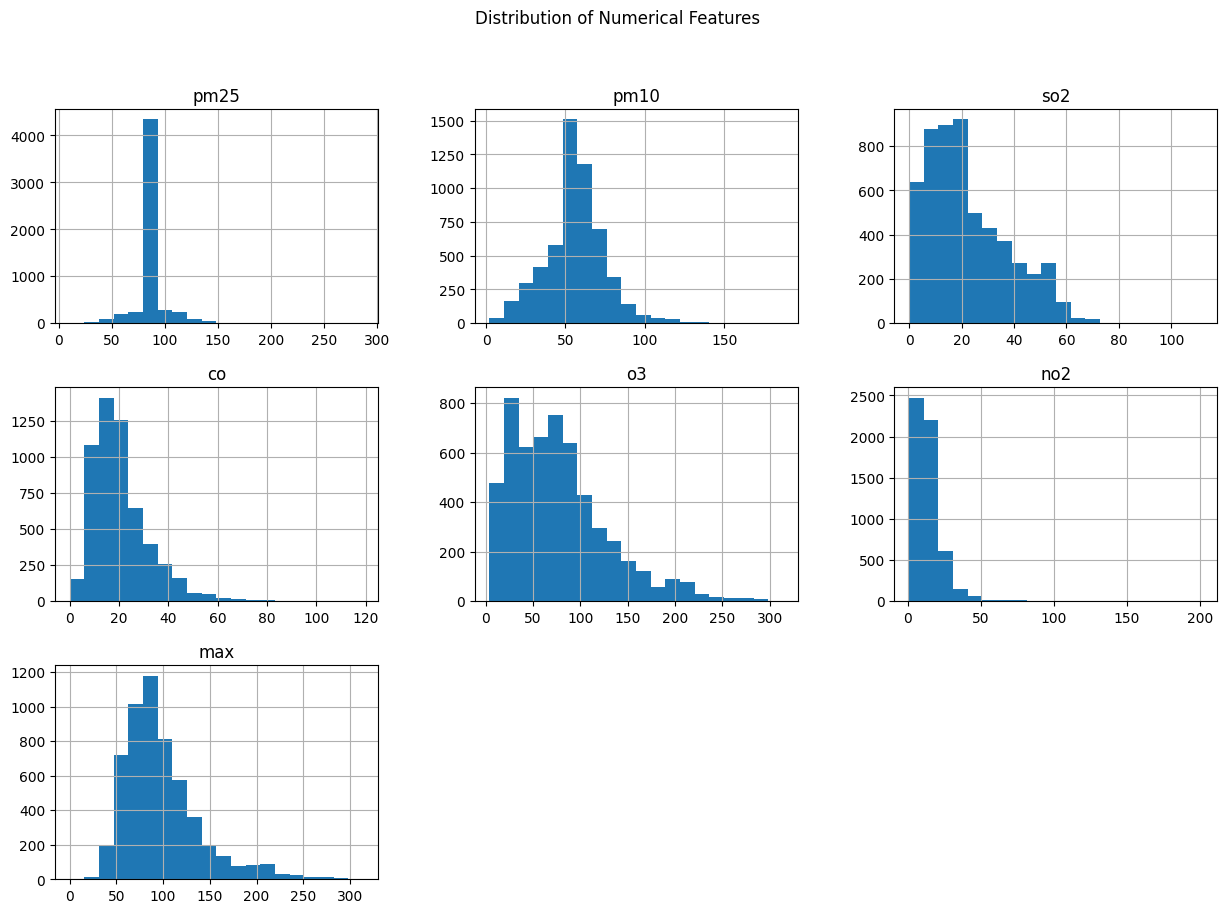

In [ ]:
df[num_cols].hist(figsize=(15,10), bins=20)
plt.suptitle("Distribution of Numerical Features")
plt.show()

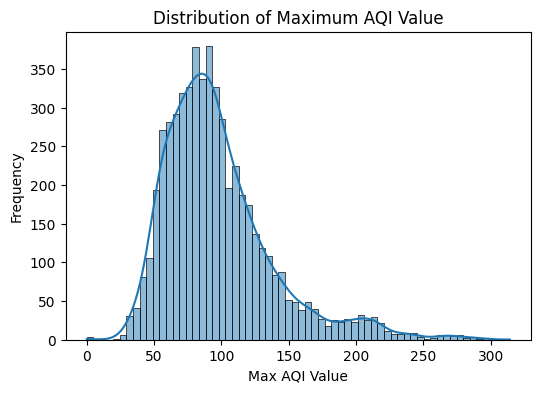

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['max'], kde=True)
plt.title("Distribution of Maximum AQI Value")
plt.xlabel("Max AQI Value")
plt.ylabel("Frequency")
plt.show()


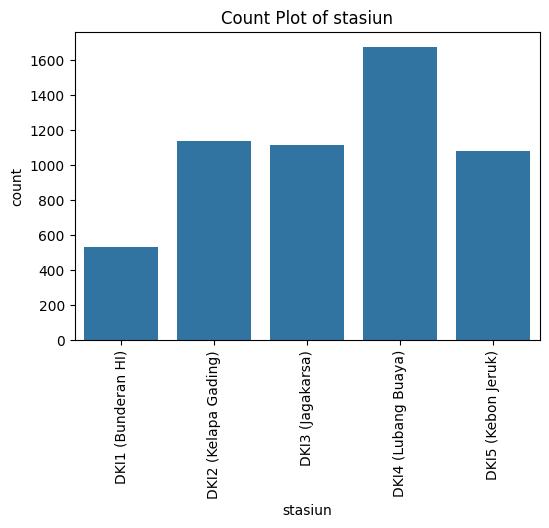

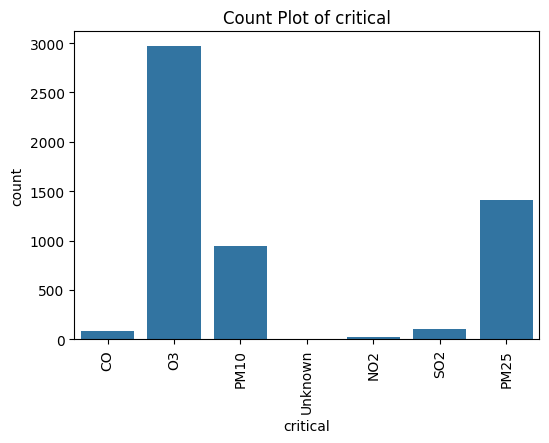

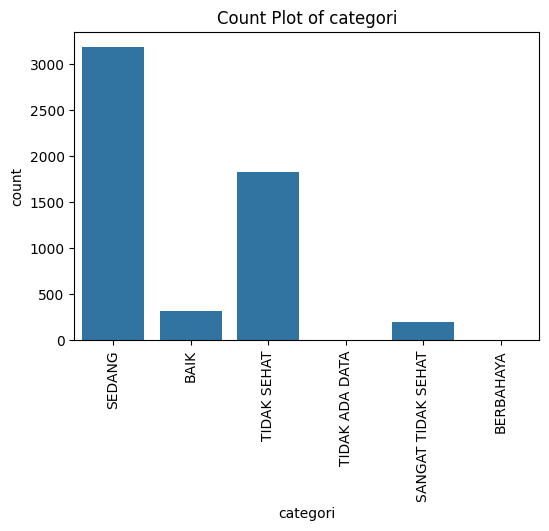

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=90)
    plt.show()

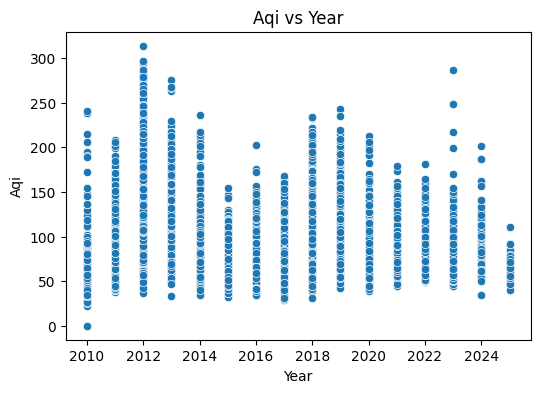

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['year'], y=df['max'])
plt.title("Aqi vs Year")
plt.xlabel("Year")
plt.ylabel("Aqi")
plt.show()

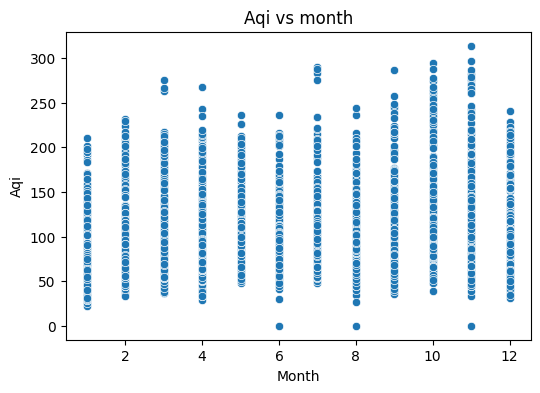

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['month'], y=df['max'])
plt.title("Aqi vs month")
plt.xlabel("Month")
plt.ylabel("Aqi")
plt.show()
plt.show()

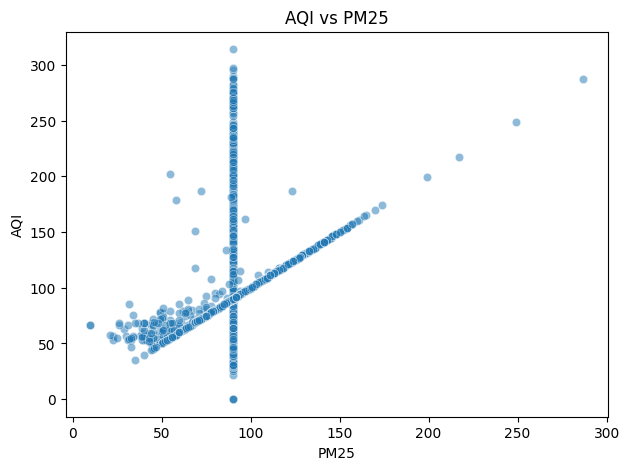

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='pm25', y='max', alpha=0.5)
plt.title('AQI vs PM25')
plt.xlabel('PM25')
plt.ylabel('AQI')
plt.show()


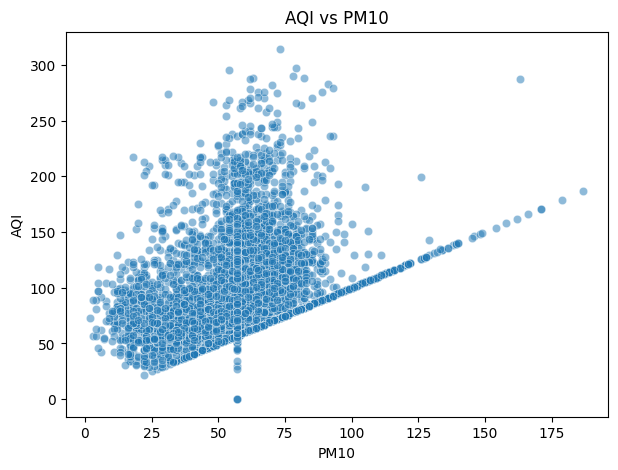

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='pm10', y='max', alpha=0.5)
plt.title('AQI vs PM10')
plt.xlabel('PM10')
plt.ylabel('AQI')
plt.show()


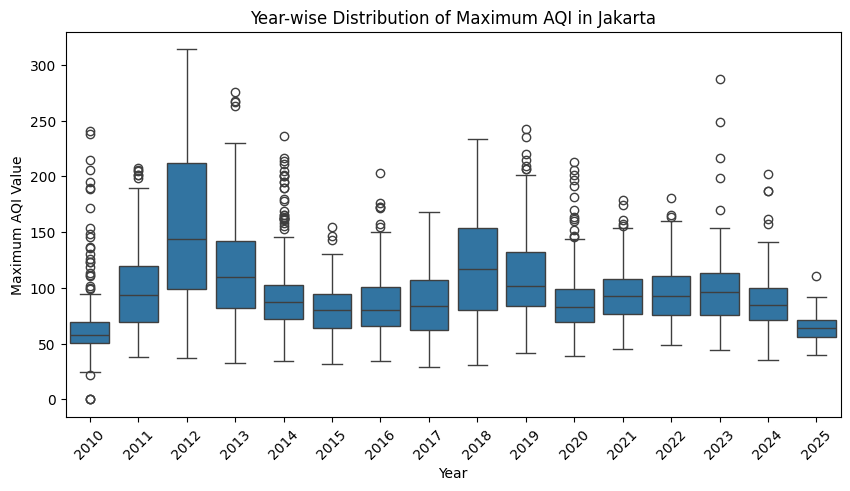

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x='year', y='max', data=df)
plt.title("Year-wise Distribution of Maximum AQI in Jakarta")
plt.xlabel("Year")
plt.ylabel("Maximum AQI Value")
plt.xticks(rotation=45)
plt.show()


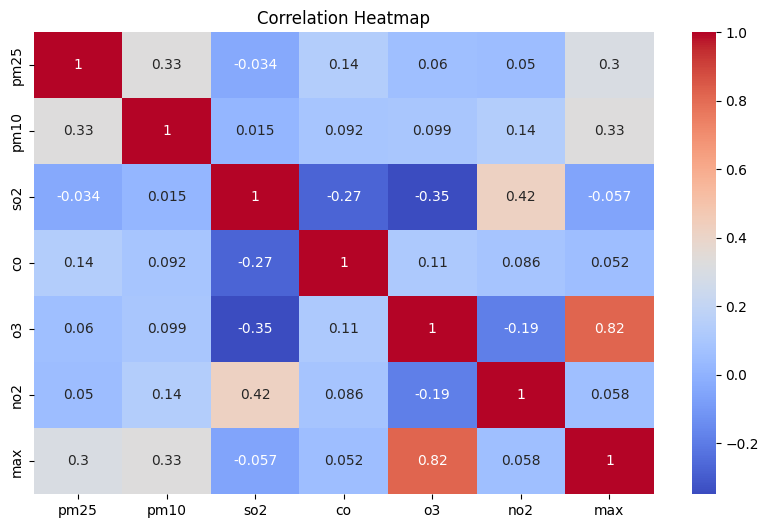

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

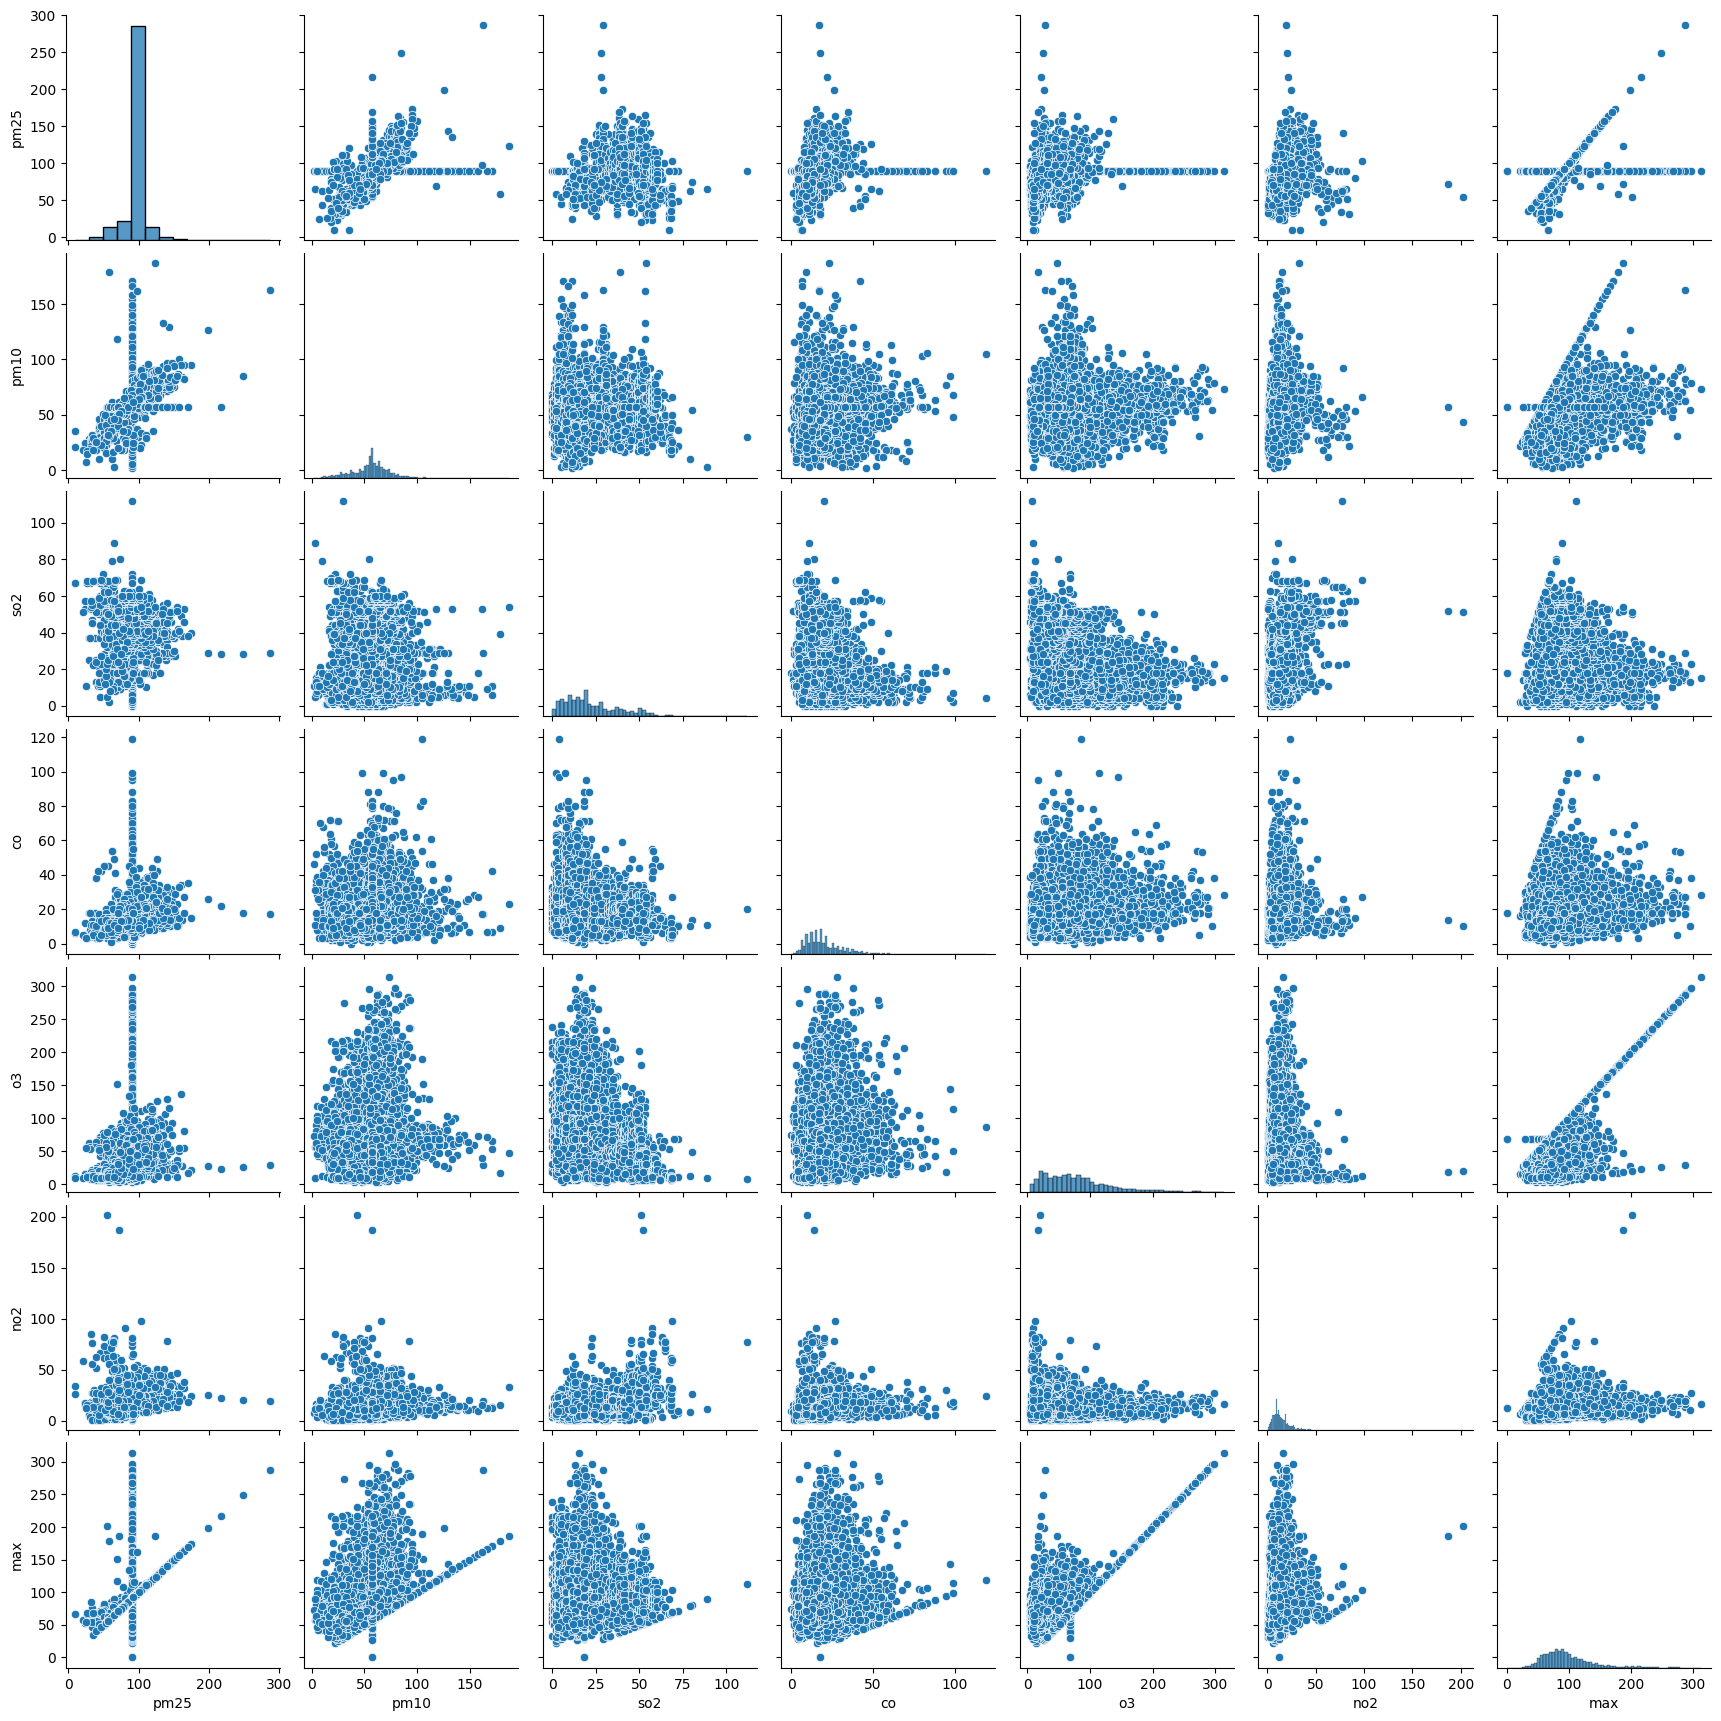

In [ ]:
sns.pairplot(df[num_cols])
plt.show()

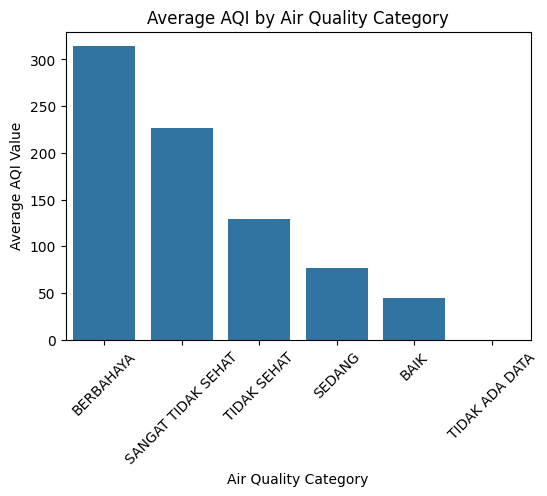

In [ ]:
# Average AQI by air quality category
avg_aqi_category = df.groupby('categori')['max'].mean().sort_values(ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x=avg_aqi_category.index, y=avg_aqi_category.values)
plt.title("Average AQI by Air Quality Category")
plt.xlabel("Air Quality Category")
plt.ylabel("Average AQI Value")
plt.xticks(rotation=45)
plt.show()


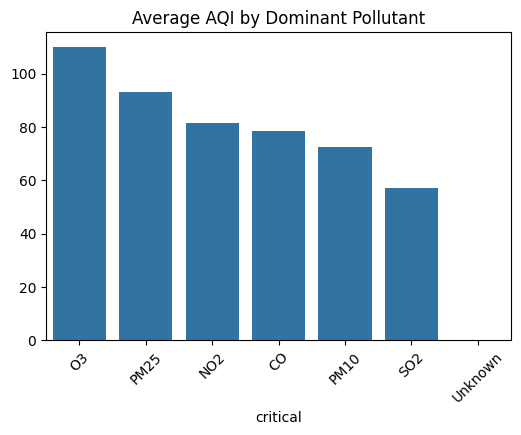

In [ ]:
avg_aqi_critical = df.groupby('critical')['max'].mean().sort_values(ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x=avg_aqi_critical.index, y=avg_aqi_critical.values)
plt.title("Average AQI by Dominant Pollutant")
plt.xticks(rotation=45)
plt.show()


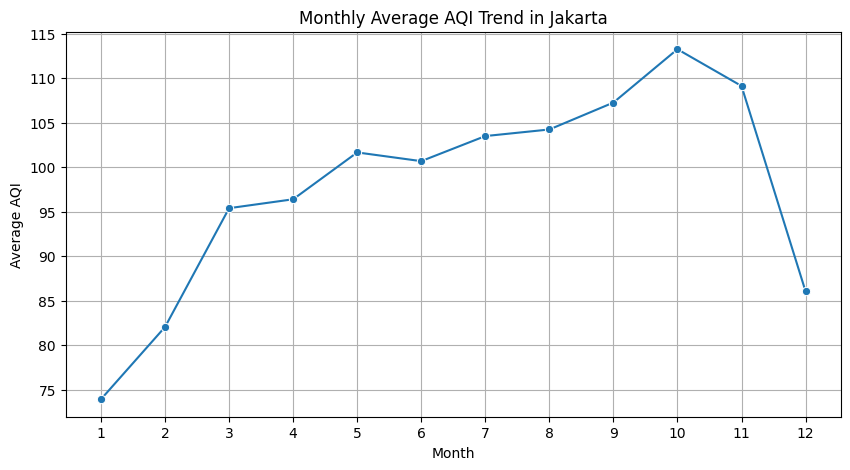

In [ ]:
monthly_aqi = df.groupby('month')['max'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_aqi, x='month', y='max', marker='o')
plt.title('Monthly Average AQI Trend in Jakarta')
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()


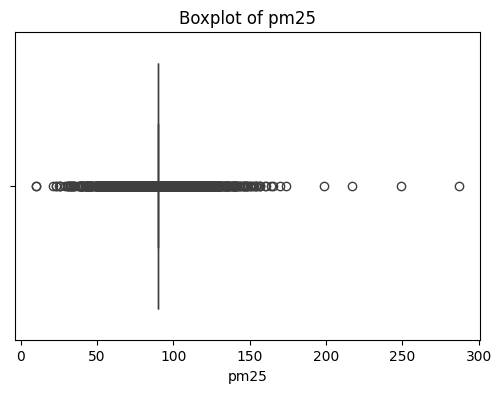

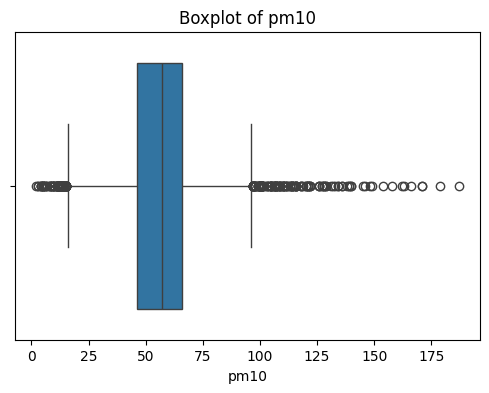

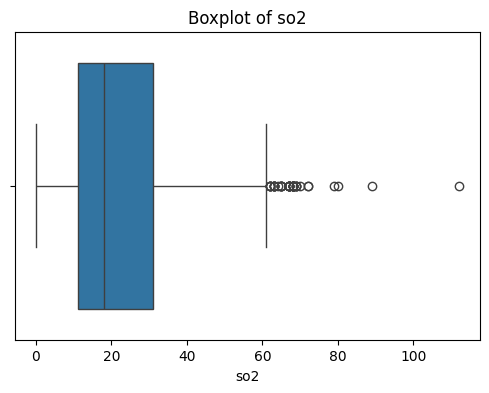

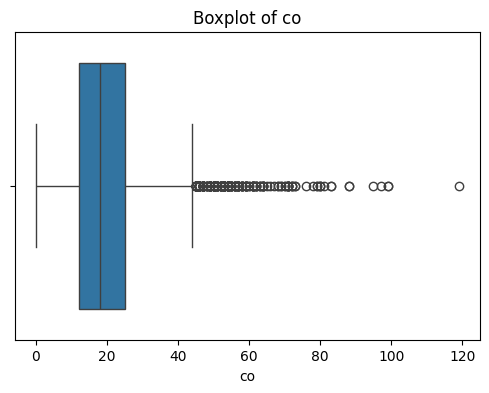

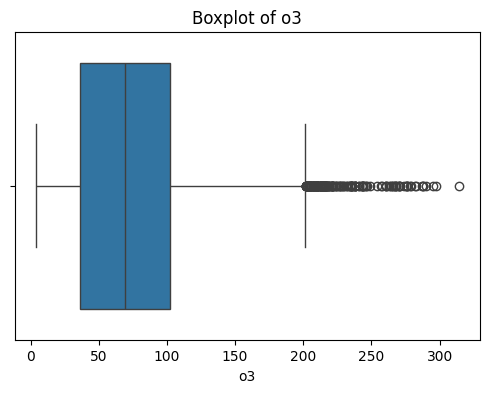

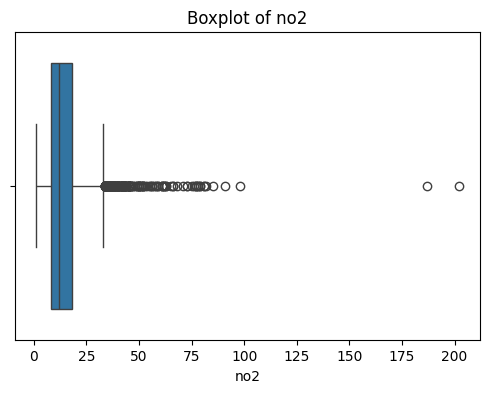

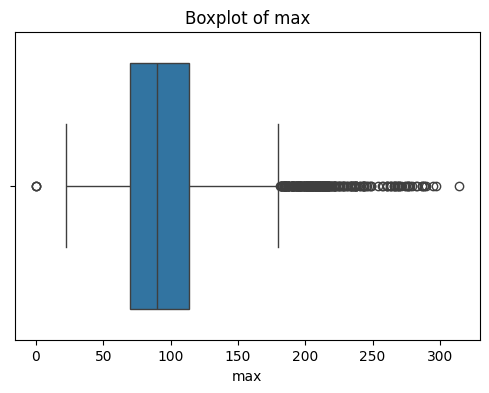

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
# Skewness

skewness = df[num_cols].skew()
skewness

,0
pm25,0.984461
pm10,0.574143
so2,0.823246
co,1.646084
o3,1.113261
no2,4.111773
max,1.440861


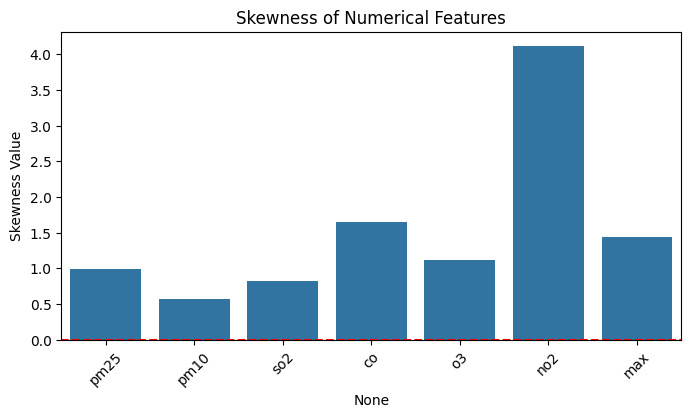

In [ ]:
plt.figure(figsize=(8,4))
sns.barplot(x=skewness.index, y=skewness.values)
plt.axhline(0, color='red', linestyle='--')
plt.title("Skewness of Numerical Features")
plt.ylabel("Skewness Value")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Kurtosis
kurtosis = df[num_cols].kurtosis()
kurtosis

,0
pm25,18.087226
pm10,2.990878
so2,0.030892
co,4.719510
o3,1.324141
no2,46.609346
max,2.834204


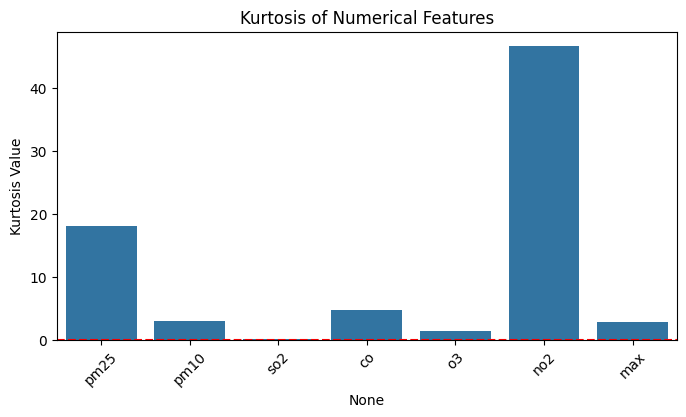

In [ ]:
plt.figure(figsize=(8,4))
sns.barplot(x=kurtosis.index, y=kurtosis.values)
plt.axhline(0, color='red', linestyle='--')
plt.title("Kurtosis of Numerical Features")
plt.ylabel("Kurtosis Value")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Capping
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outdf = df.loc[(df[col] > upper) | (df[col] < lower)]
    print(outdf)
    df.loc[df[col] > upper,col] = upper
    df.loc[df[col] < lower,col] = lower  # capping
    return df

In [ ]:
# Create a copy BEFORE capping
df_before_cap = df.copy()

# Apply capping column by column
for col in num_cols:
    df = remove_outliers(df, col)

# Create a copy AFTER capping
df_after_cap = df.copy()


                   stasiun   pm25  pm10   so2    co    o3   no2    max  \
4018  DKI2 (Kelapa Gading)   58.0  38.0   2.0  11.0  65.0   6.0   65.0   
4019      DKI3 (Jagakarsa)   86.0  58.0  15.0  22.0  38.0   5.0   86.0   
4020      DKI3 (Jagakarsa)   93.0  64.0  14.0  20.0  35.0   5.0   93.0   
4021  DKI2 (Kelapa Gading)   49.0  30.0  18.0   9.0  77.0   7.0   77.0   
4022      DKI3 (Jagakarsa)   89.0  59.0  15.0  19.0  42.0   7.0   89.0   
...                    ...    ...   ...   ...   ...   ...   ...    ...   
5533      DKI3 (Jagakarsa)   70.0  45.0  52.0  18.0  19.0  40.0   70.0   
5534    DKI5 (Kebon Jeruk)   75.0  18.0  28.0  13.0  25.0   4.0   75.0   
5535      DKI3 (Jagakarsa)   65.0  46.0  57.0  11.0  11.0  51.0   65.0   
5536    DKI5 (Kebon Jeruk)  111.0  29.0  24.0  21.0  34.0   8.0  111.0   
5537    DKI5 (Kebon Jeruk)   71.0  20.0  24.0   9.0  31.0   6.0   71.0   

     critical     categori  year  month  day  
4018       O3       SEDANG  2021      1    1  
4019     PM25    

In [ ]:
print("Before capping:", df.shape)
print("After capping:", df_after_cap.shape)

Before capping: (5537, 13)
After capping: (5537, 13)


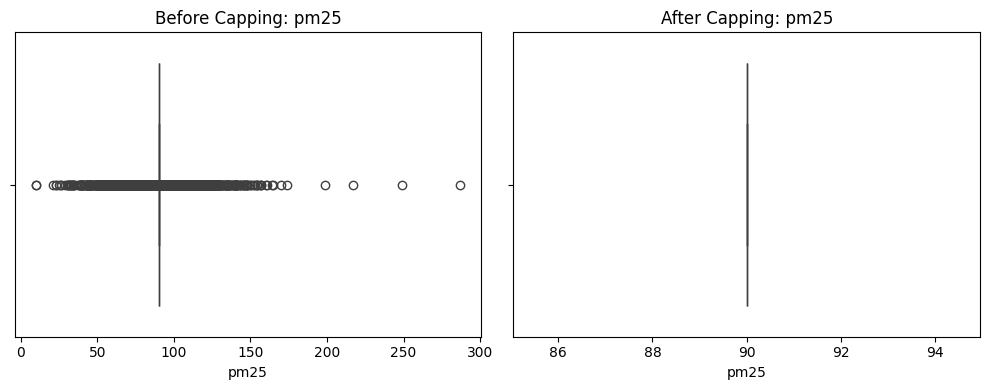

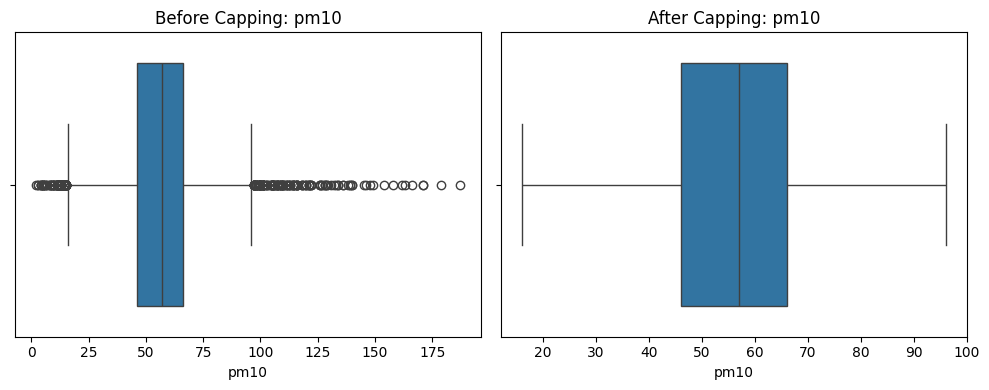

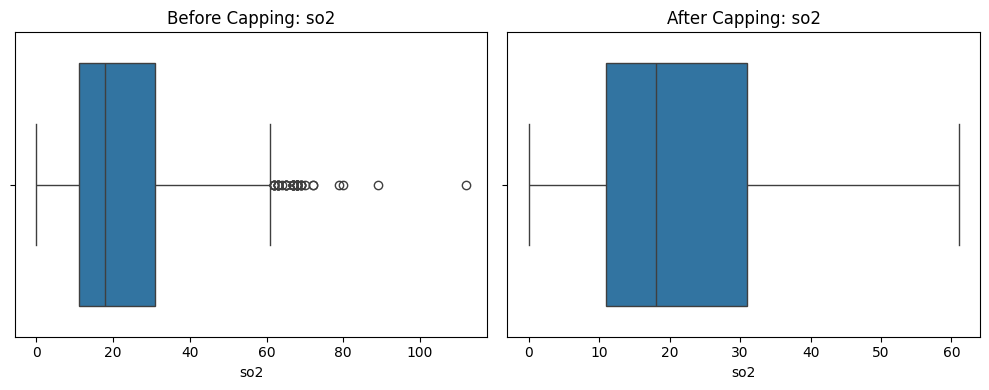

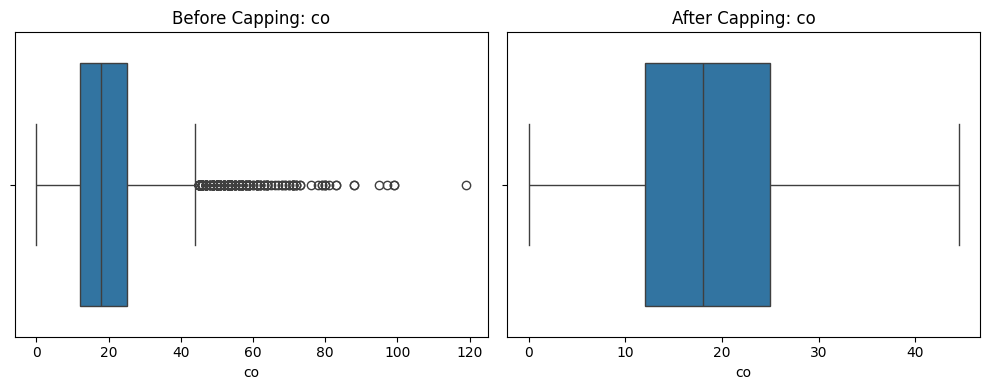

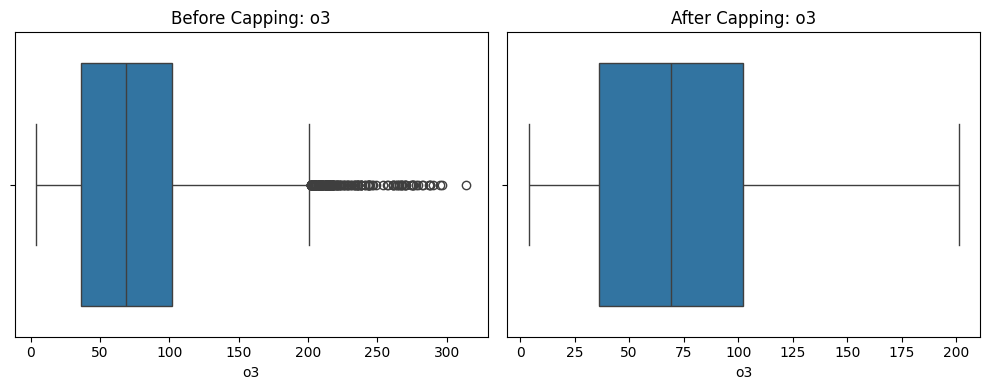

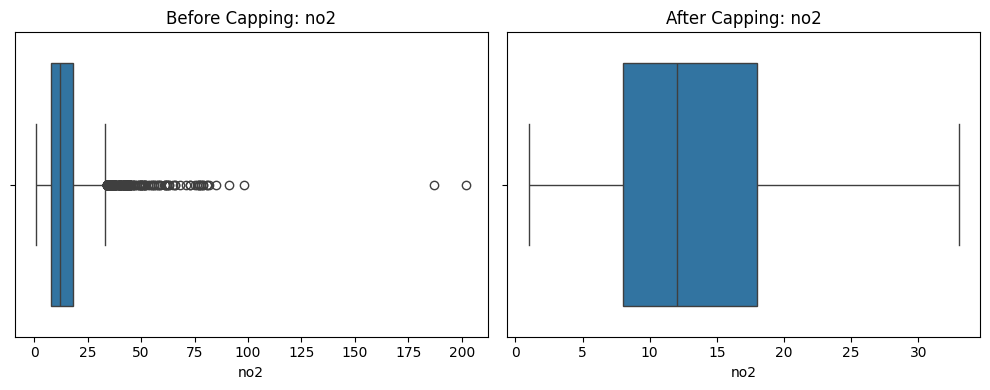

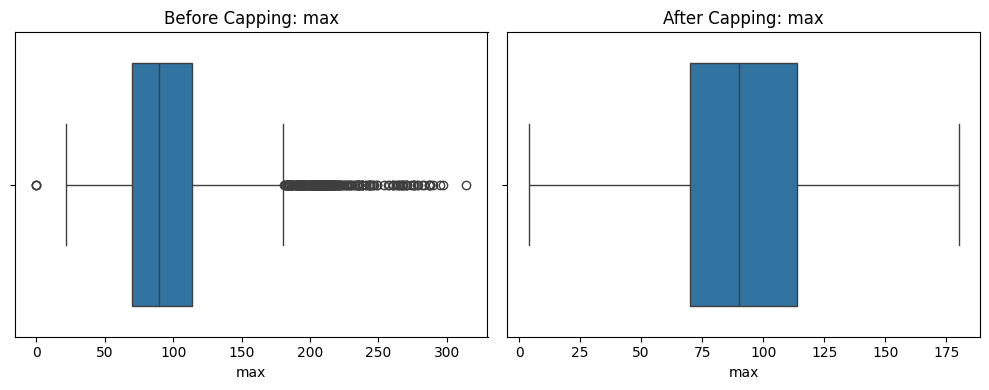

In [ ]:
for col in num_cols:
    plt.figure(figsize=(10, 4))

    # Before capping
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df_before_cap[col])
    plt.title(f"Before Capping: {col}")

    # After capping
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_after_cap[col])
    plt.title(f"After Capping: {col}")

    plt.tight_layout()
    plt.show()


# Input and Output Seperation

In [ ]:
X = df.drop('max', axis=1)
y = df['max']


In [ ]:
print("max"in X.columns)

False


In [ ]:
X = X.drop('categori', axis=1)


In [ ]:
print("categori" in X.columns)

False


In [ ]:
num_cols=X.select_dtypes(include=['float64',"int64"]).columns
cat_cols=X.select_dtypes(include=['object',"bool","category"]).columns
date_cols=["year","month","day"]

In [ ]:
num_cols,cat_cols,date_cols

(Index(['pm25', 'pm10', 'so2', 'co', 'o3', 'no2'], dtype='object'),
 Index(['stasiun', 'critical'], dtype='object'),
 ['year', 'month', 'day'])

# Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler_num = StandardScaler()
scaler_date = StandardScaler()

X_num_scaled = pd.DataFrame(
    scaler_num.fit_transform(df[num_cols]),
    columns=num_cols,
    index=df.index
)

X_date_scaled = pd.DataFrame(
    scaler_date.fit_transform(df[date_cols]),
    columns=date_cols,
    index=df.index
)


# Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_cat_encoded = pd.DataFrame(
    ohe.fit_transform(X[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X.index
)



# Concatenation

In [ ]:
X_df = pd.concat(
    [X_num_scaled, X_date_scaled, X_cat_encoded],
    axis=1
)


In [ ]:
X_df

,pm25,pm10,so2,co,o3,no2,year,month,day,stasiun_DKI1 (Bunderan HI),...,stasiun_DKI3 (Jagakarsa),stasiun_DKI4 (Lubang Buaya),stasiun_DKI5 (Kebon Jeruk),critical_CO,critical_NO2,critical_O3,critical_PM10,critical_PM25,critical_SO2,critical_Unknown
0,0.0,0.226963,-1.210486,2.382497,-1.016762,0.029739,-1.619383,-1.576023,-1.673669,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,-1.364368,-1.342982,-0.378558,-0.893244,-0.631572,-1.619383,-1.576023,-1.559991,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,-1.648534,-1.342982,-0.087921,-1.160865,-0.631572,-1.619383,-1.576023,-1.446314,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,-1.932700,-1.342982,-0.378558,-1.263797,-1.028359,-1.619383,-1.576023,-1.332636,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,-1.762200,-1.342982,-0.281679,-1.263797,-0.763834,-1.619383,-1.576023,-1.218959,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5533,0.0,-0.625535,1.969427,-0.184800,-1.181452,2.542722,1.809148,-1.287822,0.940914,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5534,0.0,-2.160033,0.379470,-0.669195,-1.057934,-1.292883,1.809148,-1.287822,1.054591,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5535,0.0,-0.568702,2.300668,-0.862954,-1.346142,2.542722,1.809148,-1.287822,1.168269,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5536,0.0,-1.534867,0.114478,0.105837,-0.872658,-0.763834,1.809148,-1.287822,1.281946,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Dimensionality reduction techniques were explored but not applied, as the feature set was compact and domain interpretability was prioritized.

# Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_df,y,test_size=0.2,random_state=42)


# Model selection

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

# Model Initialization

In [ ]:
models = {
    "Linear": LinearRegression(),
    "SVM": SVR(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "Gradient Boost": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(
        objective="reg:squarederror",
        n_estimators=100,
        random_state=42
    )
}

# Model Training

In [ ]:
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

In [ ]:
trained_models

{'Linear': LinearRegression(),
 'SVM': SVR(),
 'Decision Tree': DecisionTreeRegressor(random_state=42),
 'Random Forest': RandomForestRegressor(random_state=42),
 'KNN': KNeighborsRegressor(),
 'AdaBoost': AdaBoostRegressor(random_state=42),
 'Gradient Boost': GradientBoostingRegressor(random_state=42),
 'XGBoost': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None

# Model Evaluation

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

evaluation_results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    evaluation_results.append([name, r2, mse, mae, rmse])

results_df = pd.DataFrame(
    evaluation_results,
    columns=["Model", "R2 (Accuracy)", "MSE", "MAE", "RMSE"]
)

In [ ]:
results_df.sort_values(by="R2 (Accuracy)", ascending=False)

,Model,R2 (Accuracy),MSE,MAE,RMSE
3,Random Forest,0.973995,32.915858,2.516444,5.737234
7,XGBoost,0.972946,34.244021,3.126480,5.851839
6,Gradient Boost,0.963917,45.672518,3.913884,6.758145
2,Decision Tree,0.946997,67.088448,3.364621,8.190754
1,SVM,0.914493,108.230946,6.986926,10.403410
4,KNN,0.889372,140.028123,8.848556,11.833348
0,Linear,0.858805,178.717755,9.805258,13.368536
5,AdaBoost,0.818267,230.029684,12.242737,15.166730


# Visualization

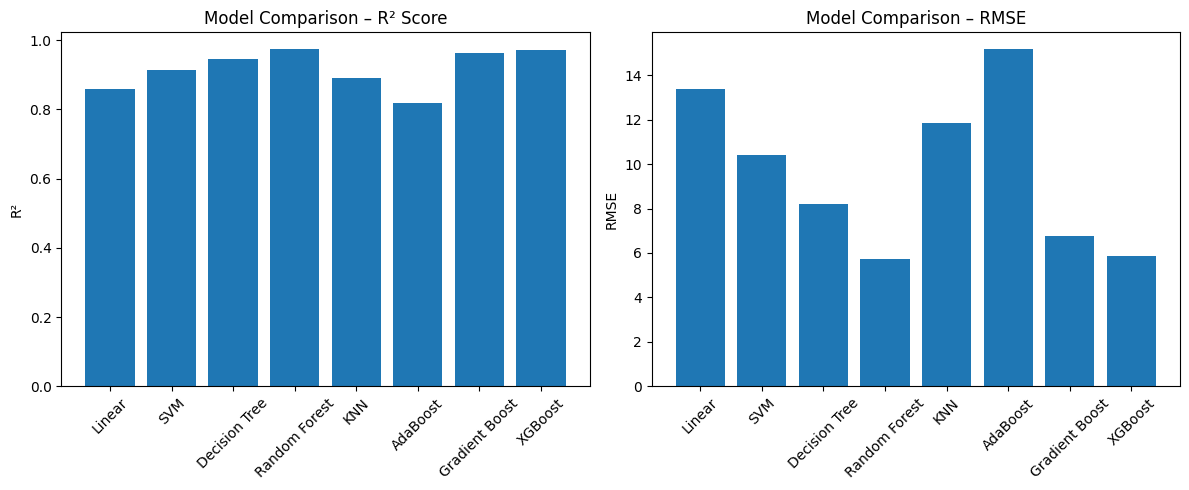

In [ ]:
plt.figure(figsize=(12,5))

# R² comparison
plt.subplot(1, 2, 1)
plt.bar(results_df["Model"], results_df["R2 (Accuracy)"])
plt.xticks(rotation=45)
plt.title("Model Comparison – R² Score")
plt.ylabel("R²")

# RMSE comparison
plt.subplot(1, 2, 2)
plt.bar(results_df["Model"], results_df["RMSE"])
plt.xticks(rotation=45)
plt.title("Model Comparison – RMSE")
plt.ylabel("RMSE")

plt.tight_layout()
plt.show()

# final model selection

In [ ]:
best_model = results_df.sort_values(
    by=["R2 (Accuracy)", "RMSE"],
    ascending=[False, True]
).iloc[0]

print("Best Model:", best_model["Model"])

Best Model: Random Forest


# Prediction

In [ ]:
user_input = {
    "stasiun": "DKI1 (Bundaran HI)",
    "critical": "PM2.5",
    "pm25": 85,
    "pm10": 120,
    "so2": 12,
    "co": 0.8,
    "o3": 30,
    "no2": 25,
    "year": 2023,
    "month": 8,
    "day": 15
}


In [ ]:
user_df = pd.DataFrame([user_input])


In [ ]:
user_cat_encoded = pd.DataFrame(
    ohe.transform(user_df[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=user_df.index
)


In [ ]:
user_num_scaled = pd.DataFrame(
    scaler_num.transform(user_df[num_cols]),
    columns=num_cols,
    index=user_df.index
)


In [ ]:
user_date_scaled = pd.DataFrame(
    scaler_date.transform(user_df[date_cols]),
    columns=date_cols,
    index=user_df.index
)


In [ ]:
user_final = pd.concat([user_num_scaled, user_date_scaled, user_cat_encoded],axis=1)


In [ ]:
predicted_aqi = trained_models[best_model["Model"]].predict(user_final)
print("Predicted AQI:", predicted_aqi[0])


Predicted AQI: 164.02
